In [7]:
import pandas as pd
import numpy as np

In [9]:
# df = pd.read_csv(path_folder + files[0])
df = pd.read_csv('preprocessing_berita_st.csv')
df.head()

,Unnamed: 0,Headline,Tanggal,Link,Isi Berita,data_clean,data_stopword,data_lemma,data_token,detokenization
0,0,7 Capaian Polda Metro Sepanjang 2025,2026-01-01,https://news.detik.com/berita/d-8287136/7-capa...,Kepolisian Daerah (Polda) Metro Jaya menutup t...,kepolisian daerah polda metro jaya menutup tah...,kepolisian daerah polda metro jaya menutup pen...,polisi daerah polda metro jaya tutup capai ker...,"['polisi', 'daerah', 'polda', 'metro', 'jaya',...",polisi daerah polda metro jaya tutup capai ker...
1,1,Gibran Angkat Bicara soal Pembangunan IKN,2026-01-01,https://finance.detik.com/infrastruktur/d-8287...,Pembangunan Ibu Kota Nusantara (IKN) di Kalima...,pembangunan ibu kota nusantara ikn di kalimant...,pembangunan kota nusantara ikn kalimantan timu...,bangun kota nusantara ikn kalimantan timur lan...,"['bangun', 'kota', 'nusantara', 'ikn', 'kalima...",bangun kota nusantara ikn kalimantan timur lan...
2,2,"Kunjungan Wisman ke Bali Melejit Saat Nataru, ...",2026-01-01,https://www.detik.com/bali/wisata/d-8287190/ku...,Kunjungan wisatawan mancanegara ke Bali meleji...,kunjungan wisatawan mancanegara ke bali meleji...,kunjungan wisatawan mancanegara bali melejit l...,kunjung wisatawan mancanegara bal lejit libur ...,"['kunjung', 'wisatawan', 'mancanegara', 'bal',...",kunjung wisatawan mancanegara bal lejit libur ...
3,3,"China Tegaskan Niat Reunifikasi, Taiwan Bertek...",2026-01-02,https://news.detik.com/dw/d-8288417/china-tega...,"Dalam pidato Tahun Baru, Presiden Taiwan Lai C...",dalam pidato tahun baru presiden taiwan lai ch...,pidato presiden taiwan lai chingte bertekad me...,pidato presiden taiwan lai chingte tekad tahan...,"['pidato', 'presiden', 'taiwan', 'lai', 'ching...",pidato presiden taiwan lai chingte tekad tahan...
4,4,Kehadiran Negara dan Efektivitas Penanganan Be...,2026-01-02,https://news.detik.com/kolom/d-8288430/kehadir...,Kehadiran Presiden Prabowo Subianto di lokasi ...,kehadiran presiden prabowo subianto di lokasi ...,kehadiran presiden prabowo subianto lokasi ben...,hadir presiden prabowo subianto lokasi bencana...,"['hadir', 'presiden', 'prabowo', 'subianto', '...",hadir presiden prabowo subianto lokasi bencana...


In [10]:
# Hapus yang beneran sampah saja, sisakan Headline dan Tanggal
df.drop(columns=['Unnamed: 0','Link','data_lemma','data_stopword','data_token'], inplace=True, errors='ignore')

# Cek kolom yang tersisa
print(df.columns)

Index(['Headline', 'Tanggal', 'Isi Berita', 'data_clean', 'detokenization'], dtype='object')


In [11]:
df.head()

,Headline,Tanggal,Isi Berita,data_clean,detokenization
0,7 Capaian Polda Metro Sepanjang 2025,2026-01-01,Kepolisian Daerah (Polda) Metro Jaya menutup t...,kepolisian daerah polda metro jaya menutup tah...,polisi daerah polda metro jaya tutup capai ker...
1,Gibran Angkat Bicara soal Pembangunan IKN,2026-01-01,Pembangunan Ibu Kota Nusantara (IKN) di Kalima...,pembangunan ibu kota nusantara ikn di kalimant...,bangun kota nusantara ikn kalimantan timur lan...
2,"Kunjungan Wisman ke Bali Melejit Saat Nataru, ...",2026-01-01,Kunjungan wisatawan mancanegara ke Bali meleji...,kunjungan wisatawan mancanegara ke bali meleji...,kunjung wisatawan mancanegara bal lejit libur ...
3,"China Tegaskan Niat Reunifikasi, Taiwan Bertek...",2026-01-02,"Dalam pidato Tahun Baru, Presiden Taiwan Lai C...",dalam pidato tahun baru presiden taiwan lai ch...,pidato presiden taiwan lai chingte tekad tahan...
4,Kehadiran Negara dan Efektivitas Penanganan Be...,2026-01-02,Kehadiran Presiden Prabowo Subianto di lokasi ...,kehadiran presiden prabowo subianto di lokasi ...,hadir presiden prabowo subianto lokasi bencana...


#Membaca Sentimen dari Isi Berita (data_clean)

In [ ]:
import pandas as pd
from transformers import pipeline
import os

# 1. Load Model
model_checkpoint = "mmhhz/model-indobert"
classifier = pipeline("text-classification", model=model_checkpoint)

# 2. Fungsi diperbarui: Ambil Label dan Confidence Score
def get_sentiment_details(teks):
    if pd.isna(teks) or teks == '':
        return "NEUTRAL", 0.0

    # Ambil hasil prediksi
    hasil = classifier(str(teks)[:512])

    label = hasil[0]['label']
    # Score dikali 100 untuk jadi persen, dibulatkan 2 angka di belakang koma
    score_pc = round(hasil[0]['score'] * 100, 2)

    return label, score_pc

In [ ]:
# 3. Eksekusi ke Dataframe menggunakan .apply(pd.Series)
print("Sedang melabeli data berita... ")

# Kita buat 2 kolom sekaligus: 'sentimen' dan 'akurasi_prediksi_persen'
df[['sentimen', 'nilai_akurasi']] = df['data_clean'].apply(
    lambda x: pd.Series(get_sentiment_details(x))
)

print("Selesai memberikan label!")

In [14]:
df.head()

,Headline,Tanggal,Isi Berita,data_clean,detokenization,sentimen,nilai_akurasi
0,7 Capaian Polda Metro Sepanjang 2025,2026-01-01,Kepolisian Daerah (Polda) Metro Jaya menutup t...,kepolisian daerah polda metro jaya menutup tah...,polisi daerah polda metro jaya tutup capai ker...,POSITIVE,99.24
1,Gibran Angkat Bicara soal Pembangunan IKN,2026-01-01,Pembangunan Ibu Kota Nusantara (IKN) di Kalima...,pembangunan ibu kota nusantara ikn di kalimant...,bangun kota nusantara ikn kalimantan timur lan...,NEUTRAL,99.94
2,"Kunjungan Wisman ke Bali Melejit Saat Nataru, ...",2026-01-01,Kunjungan wisatawan mancanegara ke Bali meleji...,kunjungan wisatawan mancanegara ke bali meleji...,kunjung wisatawan mancanegara bal lejit libur ...,NEUTRAL,99.95
3,"China Tegaskan Niat Reunifikasi, Taiwan Bertek...",2026-01-02,"Dalam pidato Tahun Baru, Presiden Taiwan Lai C...",dalam pidato tahun baru presiden taiwan lai ch...,pidato presiden taiwan lai chingte tekad tahan...,POSITIVE,69.57
4,Kehadiran Negara dan Efektivitas Penanganan Be...,2026-01-02,Kehadiran Presiden Prabowo Subianto di lokasi ...,kehadiran presiden prabowo subianto di lokasi ...,hadir presiden prabowo subianto lokasi bencana...,NEUTRAL,98.04


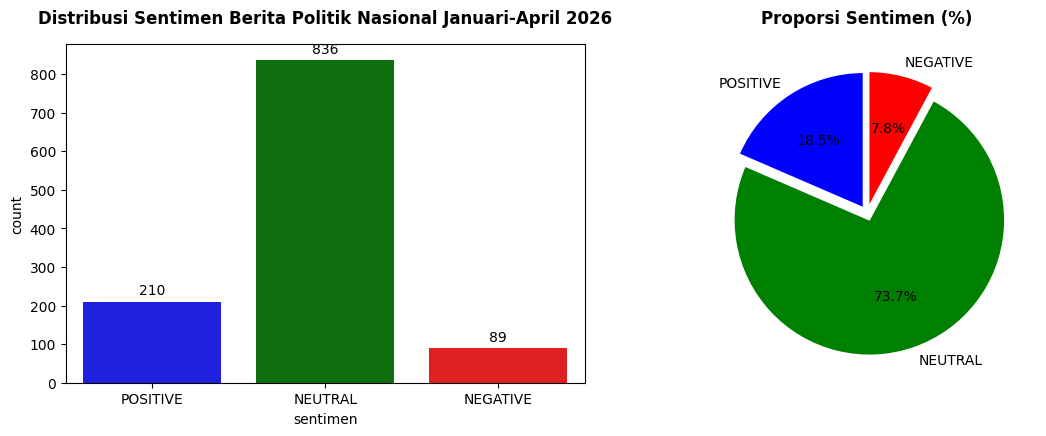

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pengaturan warna
categories = ['POSITIVE', 'NEUTRAL', 'NEGATIVE']
my_colors=['blue','green','red']
color_dict = dict(zip(categories, my_colors))

# Pembuatan subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Card1:Bar Chart
sns.countplot(x='sentimen', data=df, ax=ax1, order=categories, palette=my_colors, hue='sentimen', legend=False)
for container in ax1.containers:
    ax1.bar_label(container, padding=3)

ax1.set_title('Distribusi Sentimen Berita Politik Nasional Januari-April 2026', pad=15, fontweight='bold')


# Card2:Pie Chat
counts = df['sentimen'].value_counts().reindex(categories)
ax2.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=my_colors, # Menggunakan warna yang sama persis
    startangle=90,
    explode=[0.05] * len(categories),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

ax2.set_title('Proporsi Sentimen (%)', fontsize=12, fontweight='bold', pad=15)

# Memberikan jarak antar card agar terlihat terpisah
plt.tight_layout(pad=3.0)
plt.show()


In [16]:
# Simpan hasil gabungan kembali ke Drive agar tidak hilang saat session Colab habis
# df.to_csv(path_folder + "hasil_labeling_IndoBERT.csv", index=False)

# SEL 2: SAVE LANGSUNG (Backup)
df.to_csv("labeling_data.csv")

#EDA

#WordCLoude

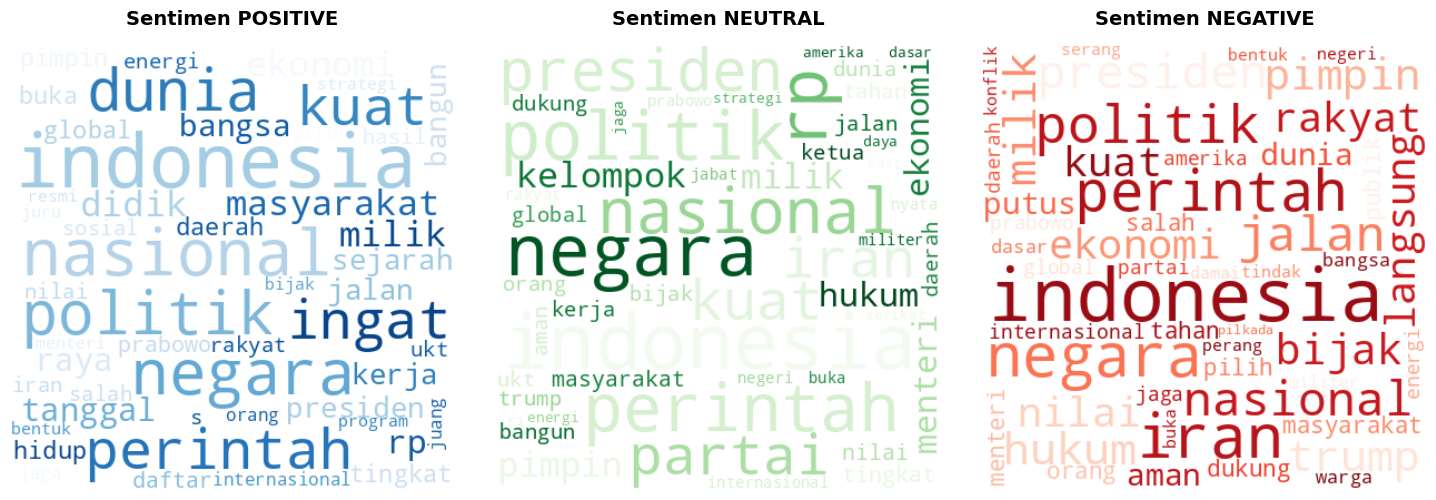

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Siapkan kategori dan skema warna (opsional agar tiap kotak beda nuansa)
categories = ['POSITIVE', 'NEUTRAL', 'NEGATIVE']
color_maps = ['Blues', 'Greens', 'Reds'] # Biru untuk Positif, Hijau Netral, Merah Negatif

# 2. Buat kanvas: 1 baris, 3 kolom
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

for i, cat in enumerate(categories):
    # Gabungkan teks berdasarkan kategori sentimen
    text_data = " ".join(df[df['sentimen'] == cat]['detokenization'].astype(str))

    # Generate WordCloud
    wc = WordCloud(
        width=400,
        height=400,
        background_color='white',
        colormap=color_maps[i],
        max_words=50,
        collocations=False # Menghindari pengulangan kata yang sama dalam pasangan
    ).generate(text_data)

    # Tampilkan di subplot masing-masing
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Sentimen {cat}', fontsize=14, fontweight='bold', pad=15)
    axes[i].axis("off") # Hilangkan angka koordinat (sumbu)

    # TAMBAHAN: Efek kotak/bingkai agar konsisten dengan grafik sebelumnya
    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color('#cccccc')
        spine.set_linewidth(2)

# Atur jarak antar kotak agar tidak dempet
plt.tight_layout(pad=3.0)
plt.show()

#Teks yang sering muncul

In [18]:
from collections import Counter

# Pastikan kolom sudah bersih
semua_teks = " ".join(df['detokenization'].astype(str))

# TOKENIZE
list_kata = semua_teks.split()

# SEKARANG SUDAH BISA DIHITUNG
word_counts = Counter(list_kata)
print(word_counts.most_common(10))

[('indonesia', 3711), ('negara', 2878), ('politik', 2662), ('perintah', 2487), ('nasional', 2349), ('rp', 2175), ('presiden', 1964), ('iran', 1839), ('kuat', 1796), ('partai', 1591)]


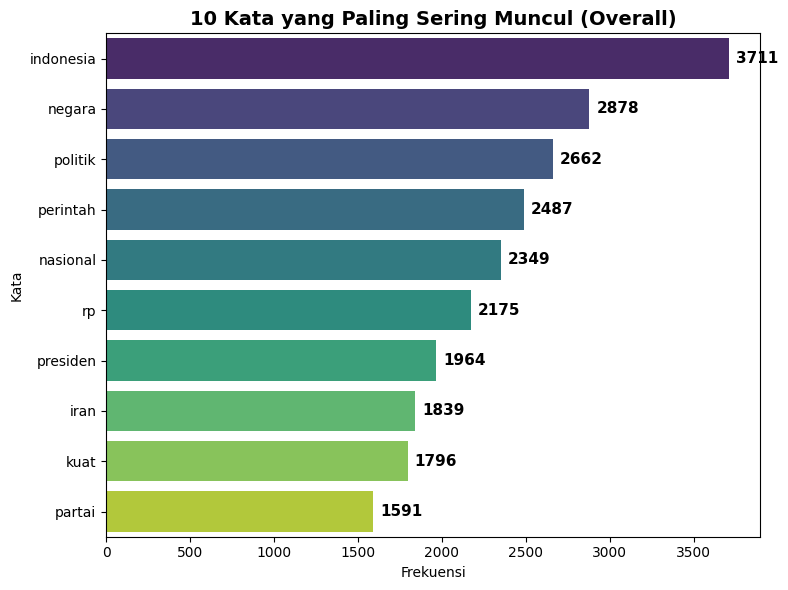

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

# Ambil 10 kata terbanyak
top_10 = word_counts.most_common(10)
kata, jumlah = zip(*top_10)

plt.figure(figsize=(8, 6))
# Pakai palette 'viridis' biar cakep dan profesional
ax = sns.barplot(x=list(jumlah), y=list(kata), palette='viridis', hue=list(kata), legend=False)

# Munculkan angkanya di ujung bar (biar konsisten sama Bigram kamu)
# --- INI KUNCI AGAR SEMUA NILAI MUNCUL ---
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=11, fontweight='bold')

plt.title("10 Kata yang Paling Sering Muncul (Overall)", fontsize=14, fontweight='bold')
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.tight_layout()
plt.show()

#Bigram

/tmp/ipykernel_19677/1705202411.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(counts), y=list(words), palette=color)


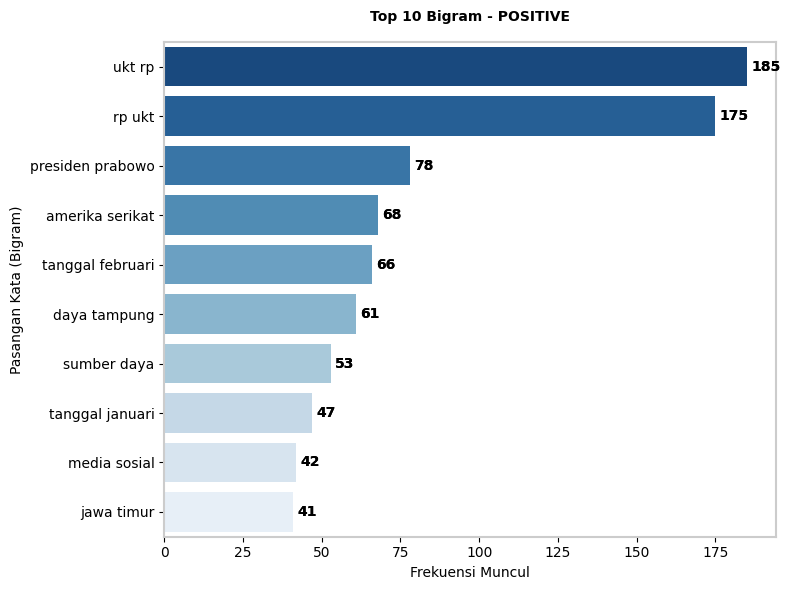

/tmp/ipykernel_19677/1705202411.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(counts), y=list(words), palette=color)


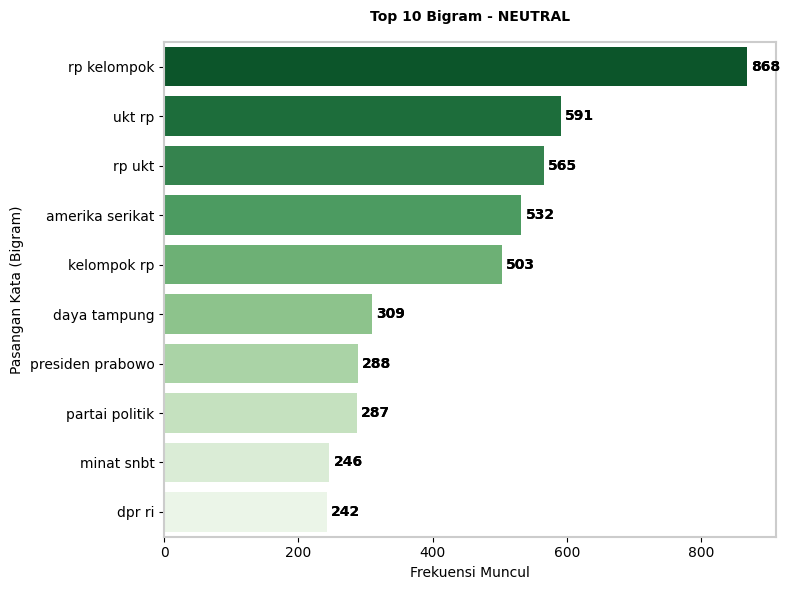

/tmp/ipykernel_19677/1705202411.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(counts), y=list(words), palette=color)


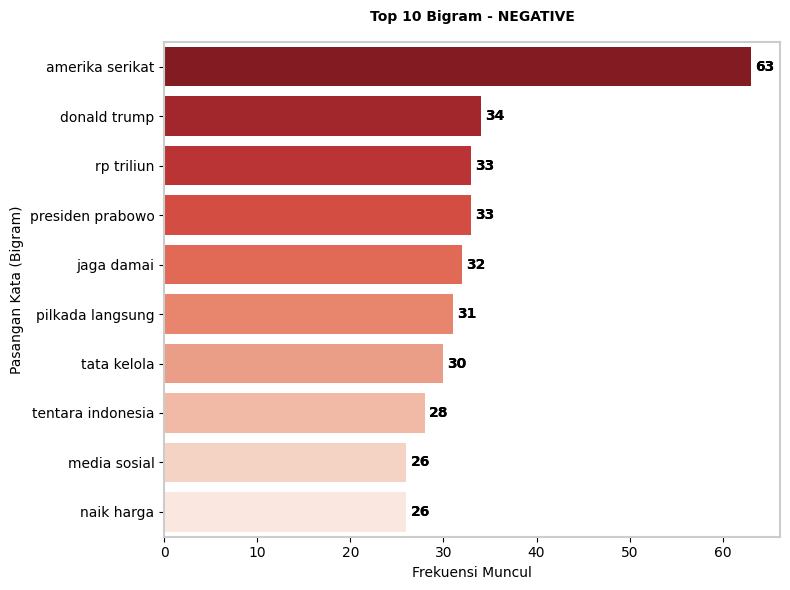

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams(text, n=2, top_k=10, title="Top Bigrams", color='viridis'):
    # Menghindari error jika teks kosong
    if len(text) < 1:
        print(f"Data untuk {title} kosong.")
        return

    vec = CountVectorizer(ngram_range=(n, n)).fit(text)
    bag_of_words = vec.transform(text)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

    words, counts = zip(*words_freq)

   # Membuat satu Card mandiri
    plt.figure(figsize=(8, 6))
    ax = sns.barplot(x=list(counts), y=list(words), palette=color)

    # TAMBAHAN: Menambahkan 'hue' dan 'legend=False' untuk menghindari warning & konsistensi warna
    ax = sns.barplot(x=list(counts), y=list(words), palette=color, hue=list(words), legend=False)

    # --- TAMBAHAN UTAMA: Munculkan nilai di setiap ujung batang ---
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

    plt.title(title, fontsize=10, fontweight='bold', pad=15)
    plt.xlabel('Frekuensi Muncul')
    plt.ylabel('Pasangan Kata (Bigram)')

    # Efek Bingkai Kotak (Card)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#cccccc')
        spine.set_linewidth(1.5)

    plt.tight_layout()
    plt.show()

# --- EKSEKUSI 3 CARD TERPISAH ---
# (Pastikan variabel df sudah ada sebelumnya)

# 1. Bigram POSITIVE
pos_text = df[df['sentimen'] == 'POSITIVE']['detokenization']
plot_top_ngrams(pos_text, n=2, title="Top 10 Bigram - POSITIVE", color='Blues_r')

# 2. Bigram NEUTRAL
neu_text = df[df['sentimen'] == 'NEUTRAL']['detokenization']
plot_top_ngrams(neu_text, n=2, title="Top 10 Bigram - NEUTRAL", color='Greens_r')

# 3. Bigram NEGATIVE
neg_text = df[df['sentimen'] == 'NEGATIVE']['detokenization']
plot_top_ngrams(neg_text, n=2, title="Top 10 Bigram - NEGATIVE", color='Reds_r')

#Frekuensi tren berita

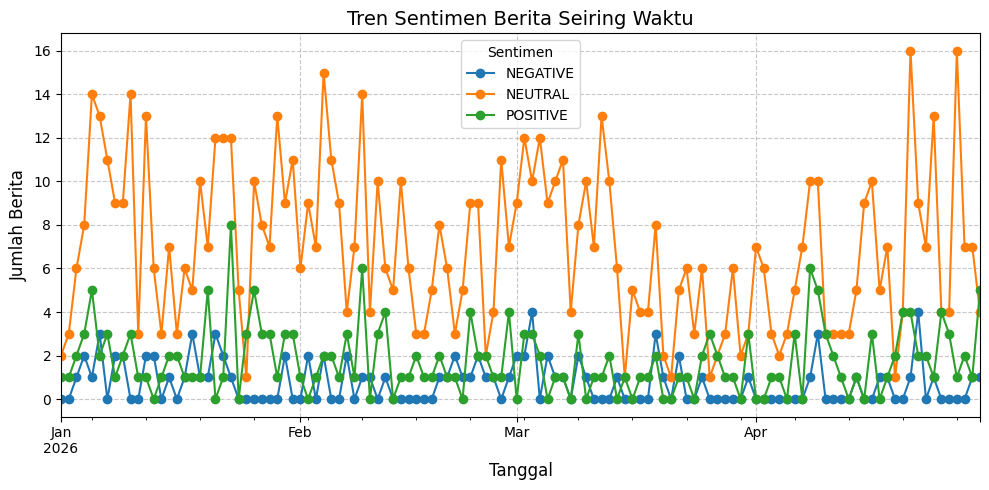

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan kolom Tanggal sudah dalam format datetime dan pastikan format tanggalnya sama
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%Y-%m-%d')

# Menghitung jumlah sentimen per tanggal
sentiment_trend = df.groupby(['Tanggal', 'sentimen']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 5))
sentiment_trend.plot(kind='line', marker='o', ax=plt.gca())

plt.title('Tren Sentimen Berita Seiring Waktu', fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Jumlah Berita', fontsize=12)
plt.legend(title='Sentimen')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()